# Convolutional Neural Networks
## Object Recognition on the CIFAR-10 Dataset

**Student:** Prithvi Adipudi
**Date:** August 12, 2026

---

## 1. Introduction

A security camera records everything in front of it, which is the problem. A perimeter system that flags every moving object floods the operator with alerts about cars, birds, and stray dogs, and an operator who sees a hundred false alarms a night stops reading them. What makes the feed useful is a model that can say *what* is in the frame, not just that something moved.

That is an object recognition problem, and it comes down to the same question this report asks of 60,000 small colour photographs: given a 32 x 32 image, which of ten categories is it?

The obstacle is that images do not behave like ordinary tabular data. A CIFAR-10 image is 3,072 numbers, and a fully connected network treats all 3,072 as unrelated columns. Move the object a few pixels and every one of those columns changes, so a network built that way has to relearn the same object at every position it might appear. A **convolutional neural network (CNN)** is the architecture built to remove that weakness. It looks at small neighbourhoods of pixels instead of the whole image at once, and it reuses the same small set of weights everywhere in the frame.

This report builds two models on identical data to show what that change is worth:

- **Model A**, a fully connected network on the flattened pixel vector, the same style of network used in the previous assignment.
- **Model B**, a convolutional neural network.

Both see the same images, the same preprocessing, and the same held-out test set, so any difference in the results comes from the architecture and nothing else.

The plan:

1. **Part 1** explains what a convolution is, gives the key formulas that define a CNN, provides a diagram of the mechanics, and lists the typical use cases along with the advantages and disadvantages.
2. **Part 2** loads CIFAR-10, splits it, preprocesses it, trains both models, and scores them on **accuracy, precision, recall, and F1-score**.
3. **Part 3** links the screencast video.

## 2. Setup

The cell below installs anything missing, imports the libraries used, and fixes the random seed so the run repeats.

In [1]:
import subprocess, sys, os, glob, io, time, warnings, contextlib

def ensure(package, import_name=None):
    """Import a package, installing it quietly first if it is missing."""
    try:
        __import__(import_name or package)
        return
    except ImportError:
        pass
    for extra in ([], ['--break-system-packages']):
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'] + extra,
                                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            return
        except subprocess.CalledProcessError:
            continue

for package, import_name in [('numpy', 'numpy'), ('pandas', 'pandas'), ('matplotlib', 'matplotlib'),
                             ('scikit-learn', 'sklearn'), ('pillow', 'PIL'), ('tensorflow', 'tensorflow')]:
    ensure(package, import_name)

for variable, value in [('TF_CPP_MIN_LOG_LEVEL', '3'), ('GLOG_minloglevel', '2'),
                        ('GRPC_VERBOSITY', 'ERROR')]:
    os.environ.setdefault(variable, value)   # keep TensorFlow's startup logs out of the report

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch
from matplotlib.ticker import MaxNLocator
from PIL import Image

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)     # seeds Python, NumPy, and TensorFlow together

# CIFAR-10's ten categories, in the order used for every label, table, and axis in this report
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

BLUE, GOLD, GREEN, RED, GRAY = '#1f4e79', '#e8a33d', '#2e7d5b', '#c0392b', '#6b6b6b'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titlesize': 11, 'font.size': 10, 'axes.grid': False})

print('Libraries loaded. TensorFlow', tf.__version__, '| scikit-learn', sklearn.__version__)

Libraries loaded. TensorFlow 2.21.0 | scikit-learn 1.8.0


## 3. Part 1 — Convolutional Neural Network Concepts

### 3.1 The problem a CNN is built to solve

Start by counting the cost of the obvious approach. A CIFAR-10 image is $32 \times 32$ pixels in three colour channels, so $32 \times 32 \times 3 = 3{,}072$ input values. Connecting those to a single fully connected layer of 512 units takes

$$3{,}072 \times 512 + 512 = 1{,}573{,}376 \text{ weights}$$

for **one layer**, on an image the size of a postage stamp. A 224 x 224 photograph would need over 77 million for the same layer.

The parameter count is the smaller problem. The real one is that a fully connected layer has no idea that its inputs are pixels. Input 1 and input 2 are neighbours in the picture, but to the layer they are just two unrelated columns, and the weight it learns for one says nothing about the other. So when the same cat appears three pixels to the left, every input value changes, and the network has to learn that cat again from scratch at the new position.

A CNN removes both problems with two ideas:

- **Local receptive fields.** A unit looks at a small square of the image, typically $3 \times 3$, instead of all of it. Nearby pixels are the ones that form edges and textures, and distant pixels are handled later by stacking layers.
- **Weight sharing.** The same small set of weights, called a **kernel** or **filter**, is applied at every position in the image. A kernel that has learned to detect a horizontal edge detects it anywhere in the frame, so the model learns the pattern once instead of once per location.

Everything else in a CNN follows from those two ideas.

### 3.2 The convolution: Formulas 1 to 3

**Formula 1 — the convolution.** A kernel $K_k$ of size $F \times F$ covering all $C_{in}$ input channels slides over the input $X$. At each position it multiplies the values it covers by its weights, adds them up, and adds a bias, producing one number of the output **feature map** $S$:

$$S(i,j,k) \;=\; \sum_{c=1}^{C_{in}} \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} X(i+m,\; j+n,\; c)\; K_k(m,n,c) \;+\; b_k$$

The three sums are just "cover a square, cover every colour channel, add it all up." One kernel produces one feature map, and a layer with $C_{out}$ kernels produces $C_{out}$ of them stacked into a volume. Each kernel learns its own pattern: in a trained network the first layer usually ends up holding edge detectors at various angles, colour-contrast detectors, and simple blob detectors.

**Formula 2 — the output size.** With an input of width $W$, kernel size $F$, zero-padding $P$, and stride $S$ (how far the kernel moves between positions), the feature map comes out as

$$O \;=\; \left\lfloor \frac{W - F + 2P}{S} \right\rfloor + 1$$

This report uses $F = 3$, $P = 1$, $S = 1$, which gives $O = W$. That is called *same* padding, and it means the convolutions do not shrink the image; only the pooling layers do, which keeps the architecture easy to reason about.

**Formula 3 — the cost of a convolutional layer.** Because every position reuses the same kernel, the parameter count depends only on the kernel size and the channel counts, never on the size of the image:

$$\#\text{params} \;=\; (F \times F \times C_{in} + 1) \times C_{out}$$

The first convolutional layer in Part 2 has $F = 3$, $C_{in} = 3$, $C_{out} = 32$, so $(3 \times 3 \times 3 + 1) \times 32 = 896$ weights. Compare that to the 1,573,376 from the fully connected layer above. It is roughly **1,750 times cheaper**, and it applies its 896 weights at all 1,024 positions in the image rather than learning each position separately.

### 3.3 Activation and pooling: Formulas 4 and 5

**Formula 4 — ReLU.** Convolution is a linear operation, so a stack of convolutions with nothing between them collapses into a single linear operation. The non-linearity is supplied by the same rectified linear unit used in the previous assignment:

$$a = f(z) = \max(0, z)$$

It zeroes out negative responses, which in practice means a feature map keeps the places where the pattern was found and discards the places where it was not.

**Formula 5 — max pooling.** A pooling layer slides a window over each feature map and keeps only the largest value in it:

$$P(i,j,k) \;=\; \max_{0 \le m,n < F} \; S(i \cdot s + m,\; j \cdot s + n,\; k)$$

With a $2 \times 2$ window and stride 2, this cuts the width and height in half and throws away three quarters of the values. That does three useful things at once. It cuts the computation for every layer that follows. It adds **translation tolerance**, since the largest response in a neighbourhood stays the largest if the object shifts by a pixel. And it widens the **receptive field**: after pooling, a $3 \times 3$ kernel covers twice as much of the original image, which is how later layers come to see whole shapes instead of edges.

The pattern *convolution, ReLU, pooling* is the repeating unit of a CNN. Stacking it is what turns pixels into edges, edges into textures and parts, and parts into objects.

### 3.4 Classification and loss: Formula 6

After the last pooling layer the volume is **flattened** into a vector and passed to ordinary fully connected layers, exactly like the network from the previous assignment. The difference is what those layers receive: not raw pixels, but the learned features the convolutional stack has extracted.

**Formula 6 — softmax and cross-entropy.** The final layer produces ten scores, softmax turns them into ten probabilities that sum to 1, and cross-entropy measures the error:

$$\hat{y}_k = \frac{e^{z_k}}{\sum_{j=1}^{10} e^{z_j}} \qquad\qquad L = -\sum_{k=1}^{10} y_k \log \hat{y}_k$$

### 3.5 How a CNN learns: Formula 7

Training works by forward propagation and back propagation, as before. A CNN adds one wrinkle: a kernel is used at every position in the image, so a single kernel weight influenced every value in the feature map, and its gradient has to collect the blame from all of them.

**Formula 7 — the gradient of a shared kernel.** With $\delta_k(i,j)$ the error signal arriving at position $(i,j)$ of feature map $k$:

$$\frac{\partial L}{\partial K_k(m,n,c)} \;=\; \sum_{i} \sum_{j} \; \delta_k(i,j) \; X(i+m,\; j+n,\; c)$$

The sum over $i$ and $j$ is weight sharing showing up in the backward pass. Each kernel weight receives one gradient contribution per position it visited, and they are added together, so every kernel is updated by evidence gathered from the entire image. Gradient descent then applies the same update rule used before, $K \leftarrow K - \eta \, \partial L / \partial K$.

This is also why a CNN generalizes well from limited data. A dense network that sees a bird in the top-left corner learns something about the top-left corner. A CNN that sees the same bird updates a kernel that fires anywhere.

### 3.6 Diagram of the mechanics

Figure 1 draws both halves of the story. Panel A is a single convolution step with Formulas 1 to 3 marked on the parts that carry them out. Panel B is the full network built in Part 2, showing how the feature volume shrinks in width and grows in depth as it moves through the stages.

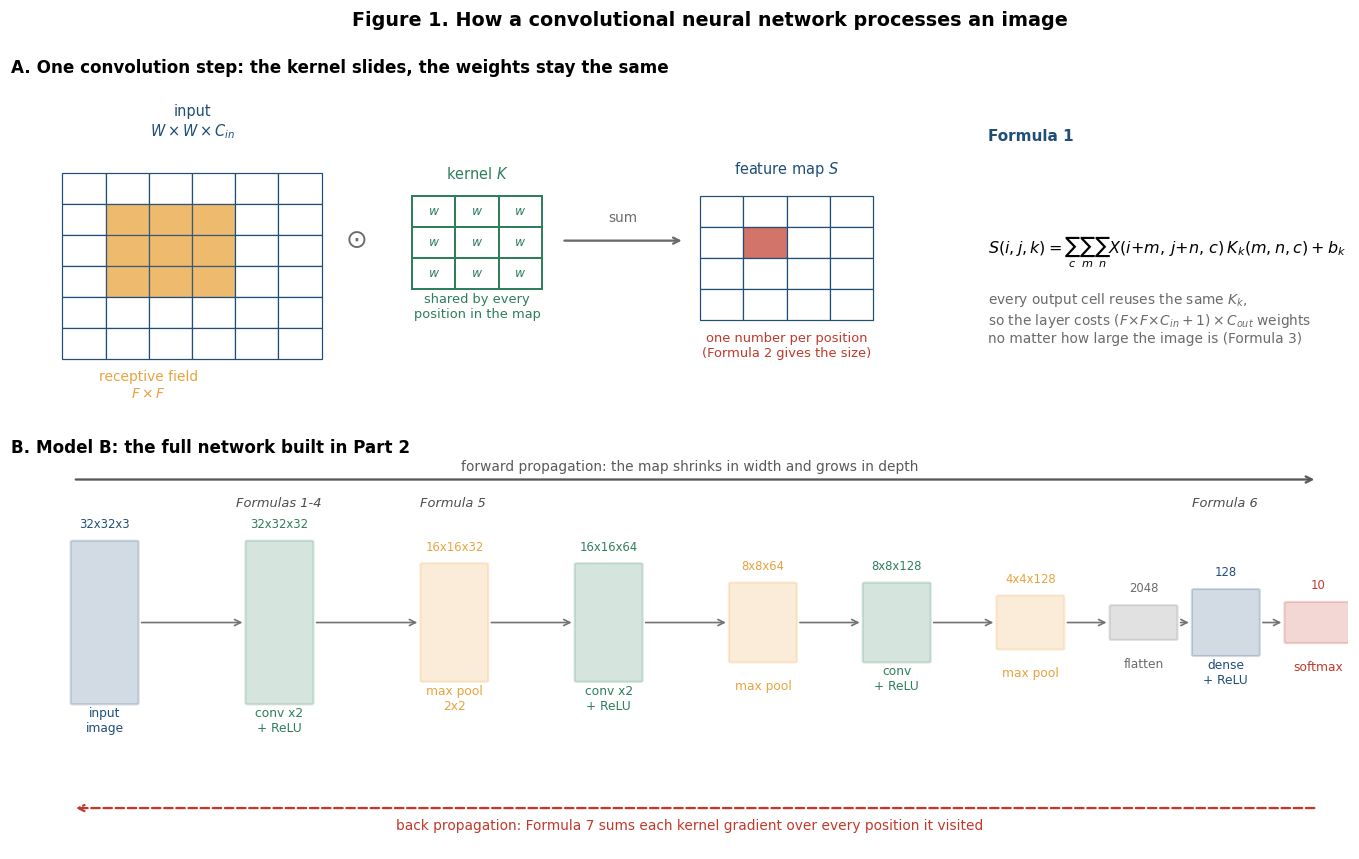

In [16]:
fig = plt.figure(figsize=(13, 7.8))
grid = fig.add_gridspec(2, 1, height_ratios=[0.88, 1])

# Panel A: one convolution step
ax = fig.add_subplot(grid[0])
ax.set_xlim(0, 13); ax.set_ylim(0.75, 5.35); ax.axis('off')
ax.set_title('A. One convolution step: the kernel slides, the weights stay the same',
             fontweight='bold', loc='left')

cell = 0.42

# the input feature map, with the receptive field the kernel currently covers highlighted
x0, y0 = 0.5, 1.6
for row in range(6):
    for col in range(6):
        inside = row in (1, 2, 3) and col in (1, 2, 3)
        ax.add_patch(Rectangle((x0 + col * cell, y0 + (5 - row) * cell), cell, cell,
                               fc=GOLD if inside else 'white', alpha=0.75 if inside else 1,
                               ec=BLUE, lw=0.8, zorder=2))
ax.text(x0 + 3 * cell, y0 + 6 * cell + 0.5, 'input\n$W \\times W \\times C_{in}$',
        ha='center', fontsize=9.5, color=BLUE)
ax.text(x0 + 2 * cell, y0 - 0.52, 'receptive field\n$F \\times F$', ha='center',
        fontsize=9, color=GOLD)

# the kernel: the weights that get reused at every position
kx, ky = 3.9, 2.55
for row in range(3):
    for col in range(3):
        ax.add_patch(Rectangle((kx + col * cell, ky + (2 - row) * cell), cell, cell,
                               fc='white', ec=GREEN, lw=1.3, zorder=2))
        ax.text(kx + col * cell + cell / 2, ky + (2 - row) * cell + cell / 2,
                '$w$', ha='center', va='center', fontsize=8, color=GREEN, zorder=3)
ax.text(kx + 1.5 * cell, ky + 3 * cell + 0.22, 'kernel $K$', ha='center', fontsize=9.5, color=GREEN)
ax.text(kx + 1.5 * cell, ky - 0.4, 'shared by every\nposition in the map',
        ha='center', fontsize=8.5, color=GREEN)

ax.text(3.35, 3.2, r'$\odot$', fontsize=17, ha='center', va='center', color=GRAY)
ax.annotate('', xy=(6.55, 3.2), xytext=(5.35, 3.2),
            arrowprops=dict(arrowstyle='->', color=GRAY, lw=1.5))
ax.text(5.95, 3.45, 'sum', ha='center', fontsize=9, color=GRAY)

# the output feature map, with the single cell this step produces
ox, oy = 6.7, 2.13
for row in range(4):
    for col in range(4):
        lit = row == 1 and col == 1
        ax.add_patch(Rectangle((ox + col * cell, oy + (3 - row) * cell), cell, cell,
                               fc=RED if lit else 'white', alpha=0.7 if lit else 1,
                               ec=BLUE, lw=0.8, zorder=2))
ax.text(ox + 2 * cell, oy + 4 * cell + 0.3, 'feature map $S$', ha='center', fontsize=9.5, color=BLUE)
ax.text(ox + 2 * cell, oy - 0.5, 'one number per position\n(Formula 2 gives the size)',
        ha='center', fontsize=8.5, color=RED)

ax.text(9.5, 4.55, 'Formula 1', fontsize=10, color=BLUE, fontweight='bold')
ax.text(9.5, 3.05,
        r'$S(i,j,k)=\sum_{c}\sum_{m}\sum_{n} X(i{+}m,\,j{+}n,\,c)\,K_k(m,n,c)+b_k$',
        fontsize=10.5, va='center')
ax.text(9.5, 2.15, 'every output cell reuses the same $K_k$,\n'
                   'so the layer costs $(F\\!\\times\\!F\\!\\times\\!C_{in}+1)\\times C_{out}$ weights\n'
                   'no matter how large the image is (Formula 3)',
        fontsize=9, va='center', color=GRAY)

# Panel B: the full network
ax = fig.add_subplot(grid[1])
ax.set_xlim(0, 13); ax.set_ylim(0, 6); ax.axis('off')
ax.set_title('B. Model B: the full network built in Part 2', fontweight='bold', loc='left')

# (x position, drawn height, shape of the volume, colour, caption)
stages = [
    (0.6,  2.5, '32x32x3',   BLUE,  'input\nimage'),
    (2.3,  2.5, '32x32x32',  GREEN, 'conv x2\n+ ReLU'),
    (4.0,  1.8, '16x16x32',  GOLD,  'max pool\n2x2'),
    (5.5,  1.8, '16x16x64',  GREEN, 'conv x2\n+ ReLU'),
    (7.0,  1.2, '8x8x64',    GOLD,  'max pool'),
    (8.3,  1.2, '8x8x128',   GREEN, 'conv\n+ ReLU'),
    (9.6,  0.8, '4x4x128',   GOLD,  'max pool'),
    (10.7, 0.5, '2048',      GRAY,  'flatten'),
    (11.5, 1.0, '128',       BLUE,  'dense\n+ ReLU'),
    (12.4, 0.6, '10',        RED,   'softmax'),
]

mid = 3.5
for x, height, shape, color, caption in stages:
    ax.add_patch(FancyBboxPatch((x, mid - height / 2), 0.62, height,
                                boxstyle='round,pad=0.02', fc=color, alpha=0.20,
                                ec=color, lw=1.4, zorder=2))
    ax.text(x + 0.31, mid + height / 2 + 0.22, shape, ha='center', fontsize=7.6, color=color)
    ax.text(x + 0.31, mid - height / 2 - 0.45, caption, ha='center', fontsize=8, color=color)

for (x1, _, _, _, _), (x2, _, _, _, _) in zip(stages[:-1], stages[1:]):
    ax.annotate('', xy=(x2 - 0.02, mid), xytext=(x1 + 0.64, mid),
                arrowprops=dict(arrowstyle='->', color='0.45', lw=1.1))

for x, text in [(2.6, 'Formulas 1-4'), (4.3, 'Formula 5'), (11.8, 'Formula 6')]:
    ax.text(x, 5.3, text, ha='center', fontsize=8.5, color='0.3', style='italic')

ax.annotate('', xy=(12.7, 5.72), xytext=(0.6, 5.72),
            arrowprops=dict(arrowstyle='->', color='0.35', lw=1.5))
ax.text(6.6, 5.86, 'forward propagation: the map shrinks in width and grows in depth',
        ha='center', fontsize=9, color='0.35')
ax.annotate('', xy=(0.6, 0.62), xytext=(12.7, 0.62),
            arrowprops=dict(arrowstyle='->', color=RED, lw=1.5, linestyle='--'))
ax.text(6.6, 0.28, 'back propagation: Formula 7 sums each kernel gradient over every position it visited',
        ha='center', fontsize=9, color=RED)

plt.suptitle('Figure 1. How a convolutional neural network processes an image',
             fontsize=12.5, fontweight='bold', y=0.995)
plt.tight_layout(); plt.show()

**Reading Figure 1.**

**Panel A** is Formula 1 drawn as a picture. The blue grid on the left is the input, and the gold square is the receptive field: the only part of the image this step can see. The green grid is the kernel, and the crucial point about it is that there is exactly one of it. It does not belong to the gold square; it will be applied to every other position in the image too, which is what Formula 3 counts and what makes the layer cheap. The two grids are multiplied cell by cell, the products are summed across all three colour channels, the bias is added, and the single number that comes out lights up one cell of the feature map on the right. Slide the gold square one step and repeat, and the feature map fills in.

The size relationship on the right is Formula 2. A 6 x 6 input with a 3 x 3 kernel and no padding produces a 4 x 4 map, which is why the output grid is drawn smaller than the input. Part 2 pads by one pixel on each side to keep the sizes equal, so that shrinking does not accumulate through the stack.

**Panel B** shows what stacking does. Three things change from left to right. The volumes get **narrower**, because each pooling layer halves the width and height, and that is Formula 5 doing its job. They get **deeper**, because each convolutional block uses more kernels than the last, going 32, then 64, then 128, so the network tracks more distinct patterns as those patterns get more complex. And the meaning changes: early layers respond to edges and colour boundaries, and by the 4 x 4 x 128 stage a single position covers a large region of the original image and responds to whole object parts.

The last three boxes are an ordinary fully connected classifier, the same kind of network used in the previous assignment. It sits on top of the 2,048 features the convolutional stack produced rather than on 3,072 raw pixels, and that substitution is the entire difference between Model A and Model B.

The dashed arrow underneath is the backward pass. Formula 7 is marked there because that is the step where weight sharing pays off: the gradient for each kernel is summed over every position the kernel visited, so one training image updates each kernel with evidence from the whole frame.

## 4. Use Cases, Advantages, and Disadvantages

### 4.1 Typical use cases for CNNs

CNNs apply wherever the data has a **grid structure and local patterns that mean the same thing anywhere they appear**:

- **Security and surveillance.** Object and person detection in camera feeds, automated number plate recognition, X-ray and millimetre-wave screening at checkpoints, and drone or intrusion detection along a perimeter. This is the use case the present report is modelled on: turning a raw feed into a short list of what is actually there.
- **Medical imaging.** Tumour detection in mammograms and CT slices, diabetic retinopathy screening, and cell classification, where the pattern of interest is local and can occur anywhere in the scan.
- **Autonomous vehicles and robotics.** Lane detection, traffic sign recognition, and pedestrian detection, usually as the backbone feeding a detection head such as YOLO or a Faster R-CNN.
- **Document and biometric processing.** Handwriting and printed text recognition, signature verification, face recognition, and fingerprint matching.
- **Non-image grids.** Audio spectrograms for speech and acoustic event detection, and one-dimensional convolutions over time series or network traffic, where "local pattern, any position" describes the data just as well.

### 4.2 Advantages and disadvantages

| Advantages | Disadvantages |
|---|---|
| Parameter sharing makes the model far smaller than a dense network on the same image; Model B in Part 2 uses about a quarter of Model A's parameters | Computationally expensive to train, since every kernel is applied at every position of every image in every epoch |
| Translation tolerance, so an object is recognized wherever it appears in the frame | Not naturally invariant to rotation or scale, which usually has to be supplied through data augmentation |
| Learns its own features, removing the need for hand-designed edge and texture detectors | Needs large labelled datasets; the 50,000 labelled images used here is on the low end |
| Hierarchical features, with edges combining into parts and parts into objects as depth increases | Hard to interpret, since a kernel deep in the stack has no simple description |
| Exploits the grid structure of the data directly, which is information a dense network simply discards | Many architectural choices to make: depth, kernel size, channel counts, pooling, dropout rate |
| Learned kernels transfer well to new tasks, so a pretrained backbone can be reused with little data | Vulnerable to adversarial perturbations, a real concern for the security applications listed above |

### 4.3 The fully connected baseline

Model A is included as the comparison, not as a serious proposal. A dense network on flattened pixels is the right tool when the input has no spatial structure to exploit, such as tabular data where column order is arbitrary. Applied to images it retains one honest advantage, simplicity, and inherits the weaknesses described in Section 3.1: a very large first layer, no notion of which inputs are neighbours, and no tolerance for an object that moves.

## 5. Part 2.1 — Loading the Dataset and Splitting It

**The dataset.** CIFAR-10 (Krizhevsky, 2009) holds 60,000 colour photographs at $32 \times 32$ pixels in ten mutually exclusive categories: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck. The Kaggle competition release distributes it as train.7z containing 50,000 labelled PNG images named 1.png through 50000.png, a trainLabels.csv mapping each image id to its category name, and a test.7z of 300,000 unlabelled images.

**Only the 50,000 labelled images are usable here.** The images in test.7z have no published labels; they exist so that the competition can score submissions on a hidden answer key. Accuracy, precision, recall, and F1-score all require ground truth, so the test set for this report is carved out of the 50,000 labelled images instead. That is the standard way to hold out data when the competition test set is blind, and it is what makes Section 7 possible.

The loader below finds the dataset folder, extracts train.7z if it has not been unpacked yet, reads the 50,000 PNGs into a single array, and caches that array to disk so later runs load in seconds instead of minutes.

In [3]:
def find_dataset_folder():
    """Locate the folder holding trainLabels.csv, searching the usual download locations."""
    home = os.path.expanduser('~')
    roots = [os.getcwd(), os.path.join(home, 'Downloads'), os.path.join(home, 'Desktop'), home]
    patterns = ['trainLabels.csv',
                os.path.join('*', 'trainLabels.csv'),
                os.path.join('*', '*', 'trainLabels.csv')]
    for root in roots:
        if not os.path.isdir(root):
            continue
        for pattern in patterns:
            hits = sorted(glob.glob(os.path.join(root, pattern)))
            if hits:
                return os.path.dirname(os.path.abspath(hits[0]))
    raise FileNotFoundError(
        'trainLabels.csv not found. Place the Kaggle CIFAR-10 download (train.7z and '
        'trainLabels.csv) next to this notebook, in Downloads, or on the Desktop.')


def ensure_extracted(folder):
    """Return the folder of PNGs, unpacking train.7z first if that has not been done."""
    train_dir = os.path.join(folder, 'train')
    if os.path.isdir(train_dir) and glob.glob(os.path.join(train_dir, '*.png')):
        return train_dir
    archive = os.path.join(folder, 'train.7z')
    if not os.path.isfile(archive):
        raise FileNotFoundError('Neither a train folder nor train.7z was found in ' + folder)
    print('Extracting train.7z, this runs once and takes a few minutes ...')
    ensure('py7zr')
    import py7zr
    with py7zr.SevenZipFile(archive, 'r') as bundle:
        bundle.extractall(path=folder)
    return train_dir


def load_cifar10(folder):
    """Read the 50,000 labelled images into one uint8 array, caching the result to disk."""
    cache = os.path.join(folder, 'cifar10_train_cache.npz')
    label_frame = pd.read_csv(os.path.join(folder, 'trainLabels.csv'))
    if os.path.isfile(cache):
        bundle = np.load(cache)
        return bundle['images'], bundle['labels'], 'cached array (' + cache + ')'

    train_dir = ensure_extracted(folder)
    image_ids = label_frame['id'].to_numpy()
    images = np.zeros((len(image_ids), 32, 32, 3), dtype=np.uint8)
    print('Reading', len(image_ids), 'PNG files ...')
    for position, image_id in enumerate(image_ids):
        with Image.open(os.path.join(train_dir, str(image_id) + '.png')) as handle:
            images[position] = np.asarray(handle.convert('RGB'), dtype=np.uint8)
        if (position + 1) % 10000 == 0:
            print('  %6d / %d' % (position + 1, len(image_ids)))

    name_to_index = {name: index for index, name in enumerate(CLASS_NAMES)}
    labels = label_frame['label'].map(name_to_index).to_numpy(dtype=np.int64)
    np.savez(cache, images=images, labels=labels)
    return images, labels, train_dir


dataset_folder = find_dataset_folder()
images, labels, source = load_cifar10(dataset_folder)

print()
print('Loaded from:', source)
print('Images:', images.shape, '| dtype', images.dtype, '| pixel values from',
      images.min(), 'to', images.max())
print('Labels:', labels.shape, '| classes', np.unique(labels).tolist())
print('Missing files or unreadable images:', int((images.sum(axis=(1, 2, 3)) == 0).sum()))

Extracting train.7z, this runs once and takes a few minutes ...
Reading 50000 PNG files ...
   10000 / 50000
   20000 / 50000
   30000 / 50000
   40000 / 50000
   50000 / 50000

Loaded from: /Users/prithviadipudi/Downloads/cifar-10/train
Images: (50000, 32, 32, 3) | dtype uint8 | pixel values from 0 to 255
Labels: (50000,) | classes [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Missing files or unreadable images: 0


### 5.1 Splitting into training and testing sets

The 50,000 labelled images are split **45,000 for training and 5,000 for testing**. The split is **stratified**, so both sets hold 10% of every category, and it is seeded so the same split returns on every run.

The test set is set aside here and touched exactly once, in Section 7, to produce the reported metrics. During training, Keras holds back a further 10% of the *training* images as a validation set to monitor progress between epochs, so no decision anywhere in this notebook is made using the test set.

In [4]:
images_train, images_test, y_train, y_test = train_test_split(
    images, labels, test_size=5000, stratify=labels, random_state=RANDOM_STATE)

print('Training set:', images_train.shape[0], 'images')
print('Testing set: ', images_test.shape[0], 'images')
print()
distribution = pd.DataFrame({
    'training': np.bincount(y_train, minlength=10),
    'testing': np.bincount(y_test, minlength=10),
    'training %': (np.bincount(y_train, minlength=10) / len(y_train) * 100).round(2),
    'testing %': (np.bincount(y_test, minlength=10) / len(y_test) * 100).round(2),
}, index=CLASS_NAMES)
distribution.index.name = 'class'
print(distribution.to_string())

Training set: 45000 images
Testing set:  5000 images

            training  testing  training %  testing %
class                                               
airplane        4500      500        10.0       10.0
automobile      4500      500        10.0       10.0
bird            4500      500        10.0       10.0
cat             4500      500        10.0       10.0
deer            4500      500        10.0       10.0
dog             4500      500        10.0       10.0
frog            4500      500        10.0       10.0
horse           4500      500        10.0       10.0
ship            4500      500        10.0       10.0
truck           4500      500        10.0       10.0


### 5.2 A first look at the data

Two questions before modelling: do the images look like their labels, and is any class under-represented? A skewed dataset would make plain accuracy misleading and would change how precision, recall, and F1 should be averaged.

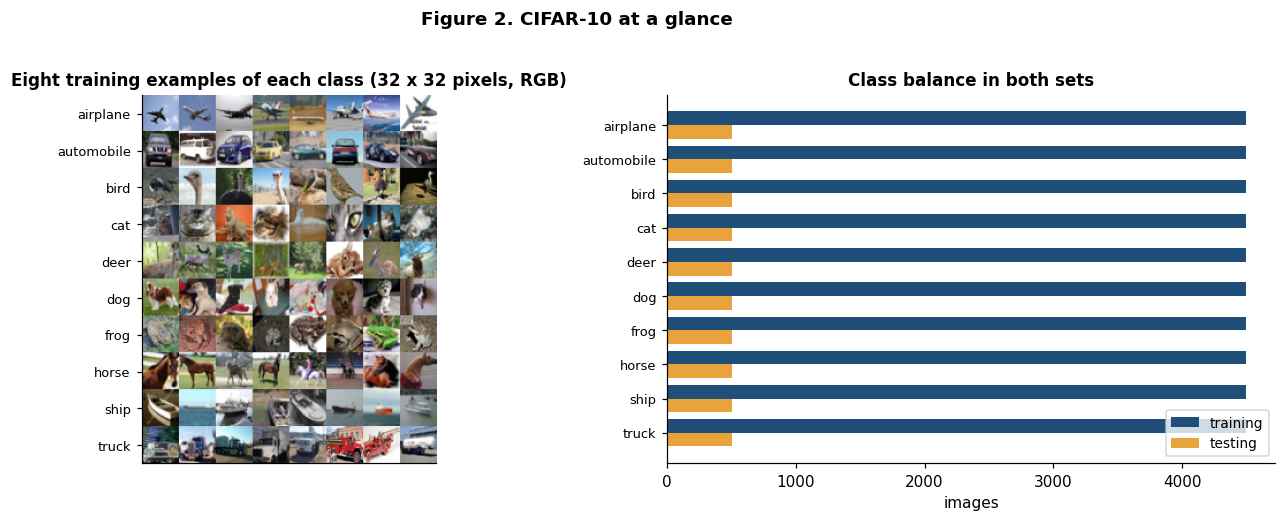

Largest class / smallest class in training: 1.00 to 1
Mean pixel value: 120.7 | standard deviation: 64.2


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [1.35, 1]})

# left: eight training examples from each of the ten classes
rows, columns = 10, 8
grid = np.zeros((32 * rows, 32 * columns, 3), dtype=np.uint8)
for class_index in range(rows):
    examples = images_train[y_train == class_index][:columns]
    for column, example in enumerate(examples):
        grid[class_index * 32:(class_index + 1) * 32, column * 32:(column + 1) * 32] = example
axes[0].imshow(grid)
axes[0].set_yticks([32 * i + 16 for i in range(rows)])
axes[0].set_yticklabels(CLASS_NAMES, fontsize=8.5)
axes[0].set_xticks([])
axes[0].set_title('Eight training examples of each class (32 x 32 pixels, RGB)', fontweight='bold')

# right: class balance in both sets
counts_train = np.bincount(y_train, minlength=10)
counts_test = np.bincount(y_test, minlength=10)
positions = np.arange(10)
width = 0.4
axes[1].barh(positions - width / 2, counts_train, width, color=BLUE, label='training')
axes[1].barh(positions + width / 2, counts_test, width, color=GOLD, label='testing')
axes[1].set_yticks(positions); axes[1].set_yticklabels(CLASS_NAMES, fontsize=8.5)
axes[1].invert_yaxis()
axes[1].set_xlabel('images'); axes[1].set_title('Class balance in both sets', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 2. CIFAR-10 at a glance', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print('Largest class / smallest class in training: %.2f to 1'
      % (counts_train.max() / counts_train.min()))
print('Mean pixel value: %.1f | standard deviation: %.1f' % (images.mean(), images.std()))

**Reading Figure 2.** The images match their labels, and they are visibly harder than the handwritten digits of the previous assignment. The objects sit against cluttered backgrounds, they appear at different scales and angles, they are partially cut off in some frames, and at 32 x 32 pixels a cat and a dog can come down to a few dozen pixels of difference. That difficulty is the point of the dataset: it is small enough to train on a laptop but hard enough that the choice of architecture matters.

The bar chart confirms the split is exactly even, 4,500 training and 500 testing images per class, because CIFAR-10 ships perfectly balanced and the split is stratified. Two things follow for Section 7. Plain accuracy is a fair headline number here, which would not be true on a skewed dataset. And because the classes are balanced, **macro** and **weighted** averages of precision, recall, and F1 will come out nearly identical; both are reported, with macro treated as the headline so that no single weak class can hide behind nine strong ones.

## 6. Part 2.2 — Preprocessing and Training the Two Models

### 6.1 Preprocessing

Four steps, applied identically to both models:

1. **Decode to a fixed array.** Every PNG becomes a $32 \times 32 \times 3$ block of unsigned bytes, done in Section 5.
2. **Encode the labels as integers.** The CSV stores category names as text, so each becomes an index 0 to 9 matching CLASS_NAMES. Keras is then given sparse_categorical_crossentropy, which reads integer labels directly and applies Formula 6 internally, so no separate one-hot step is needed.
3. **Scale to $[0, 1]$.** Every pixel is divided by 255. Neural networks multiply inputs by weights and sum them, so raw values up to 255 make gradient steps far larger than intended and destabilise training. Dividing by 255 is used rather than standardization because 255 is a fixed property of the image format, not a statistic estimated from the training set, so no information can leak from training into testing.
4. **Shape the input for each model.** Model B keeps the $32 \times 32 \times 3$ grid, because the spatial layout is precisely what its convolutions exploit. Model A cannot use a grid, so its input is flattened to a vector of 3,072 values.

That flattening step is worth pausing on, because it *is* the experiment. Flattening throws away every fact about which pixels are adjacent. Model A gets exactly the same numbers as Model B, in a fixed order, with the geometry deleted.

CIFAR-10 has no missing values and no categorical features beyond the label, so no imputation or encoding is required.

In [6]:
# scale both sets to [0, 1]
X_train = images_train.astype('float32') / 255.0
X_test = images_test.astype('float32') / 255.0

# Model A takes the flattened vector; reshape returns a view, so this costs no extra memory
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print('Before: %d training images of shape %s, values %d to %d'
      % (len(images_train), images_train.shape[1:], images_train.min(), images_train.max()))
print('After:  Model B input %s, values %.1f to %.1f' % (X_train.shape, X_train.min(), X_train.max()))
print('        Model A input %s (the same pixels, flattened)' % (X_train_flat.shape,))
print()
print('Training labels are integers 0-9, for example:', y_train[:8],
      '->', [CLASS_NAMES[i] for i in y_train[:8]])

Before: 45000 training images of shape (32, 32, 3), values 0 to 255
After:  Model B input (45000, 32, 32, 3), values 0.0 to 1.0
        Model A input (45000, 3072) (the same pixels, flattened)

Training labels are integers 0-9, for example: [1 1 6 2 8 6 1 2] -> ['automobile', 'automobile', 'frog', 'bird', 'ship', 'frog', 'automobile', 'bird']


### 6.2 Training settings

Both models are trained with identical settings so that only the architecture differs:

| Setting | Value | Reason |
|---|---|---|
| Optimizer | Adam, learning rate 0.001 | Adaptive step sizes, the standard default for both architectures |
| Loss | Sparse categorical cross-entropy | Formula 6, reading integer labels directly |
| Batch size | 128 | Enough images per gradient step for a stable estimate, small enough to fit comfortably in memory |
| Epochs | 20, with early stopping | Early stopping ends training when validation accuracy stops improving for five epochs and restores the best weights, which prevents reporting an overfitted model |
| Validation | 10% of the training set | Monitors progress between epochs without ever touching the test set |

EPOCHS is set in the next cell. Training Model B on a CPU takes roughly 30 to 60 seconds per epoch; lowering it to 12 still produces a clearly better model than Model A if time is short.

In [7]:
EPOCHS = 20
BATCH_SIZE = 128

def make_early_stopping():
    """Stop when validation accuracy has not improved for five epochs, keeping the best weights."""
    return keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                                         restore_best_weights=True, verbose=0)

print('Training for up to %d epochs, batch size %d.' % (EPOCHS, BATCH_SIZE))

Training for up to 20 epochs, batch size 128.


### 6.3 Model A — the fully connected baseline

Two hidden layers of 512 and 256 ReLU units on the flattened 3,072-value vector, with a ten-way softmax output. This is the architecture from the previous assignment, pointed at colour images instead of digits.

Note the parameter count it prints: the first layer alone accounts for over 1.5 million weights, exactly as Section 3.1 predicted.

In [8]:
model_a = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax'),
], name='Model_A_fully_connected')

model_a.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_a.summary()

start = time.time()
history_a = model_a.fit(X_train_flat, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=0.1, callbacks=[make_early_stopping()], verbose=2)
seconds_a = time.time() - start

print()
print('Model A trained for %d epochs in %.1f seconds (%s parameters)'
      % (len(history_a.history['loss']), seconds_a, format(model_a.count_params(), ',')))

Model: "Model_A_fully_connected"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
317/317 - 3s - 9ms/step - accuracy: 0.3135 - loss: 1.9196 - val_accuracy: 0.3533 - val_loss: 1.8309
Epoch 2/20
317/317 - 2s - 7ms/step - accuracy: 0.3848 - loss: 1.7208 - val_accuracy: 0.3776 - val_loss: 1.7264
Epoch 3/20
317/317 - 2s - 8ms/step - accuracy: 0.4208 - loss: 1.6288 - val_accuracy: 0.4129 - val_loss: 1.6461
Epoch 4/20
317/317 - 2s - 7ms/step - accuracy: 0.4445 - loss: 1.5609 - val_accuracy: 0.4304 - val_loss: 1.6051
Epoch 5/20
317/317 - 2s - 7ms/step - accuracy: 0.4601 - loss: 1.5139 - val_accuracy: 0.4378 - val_loss: 1.5788
Epoch 6/20
317/317 - 3s - 9ms/step - accuracy: 0.4727 - loss: 1.4765 - val_accuracy: 0.4571 - val_loss: 1.5355
Epoch 7/20
317/317 - 3s - 10ms/step - accuracy: 0.4890 - loss: 1.4419 - val_accuracy: 0.4607 - val_loss: 1.5204
Epoch 8/20
317/317 - 3s - 9ms/step - accuracy: 0.5000 - loss: 1.4111 - val_accuracy: 0.4662 - val_loss: 1.5012
Epoch 9/20
317/317 - 2s - 8ms/step - accuracy: 0.5075 - loss: 1.3885 - val_accuracy: 0.4653 - val_loss: 1.5037


### 6.4 Model B — the convolutional neural network

Three convolutional blocks, then the classifier head. Each block is the *convolution, ReLU, pooling* unit from Section 3.3, with two additions:

- **Batch normalization** after each convolution rescales that layer's outputs to a consistent range, which lets the network converge in far fewer epochs. It matters here only because the epoch budget is small.
- **Dropout** randomly zeroes a fraction of the units during training, so the network cannot depend on any single feature. It is the main defence against overfitting, which is the real risk with 45,000 training images.

The channel counts go 32, 64, 128, following the usual pattern of doubling the depth each time pooling halves the width. Every convolution uses $F = 3$, $P = 1$, $S = 1$, so by Formula 2 the convolutions preserve the spatial size and only the pooling layers shrink it.

In [9]:
model_b = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # block 1: 32x32x3 -> 16x16x32
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.25),

    # block 2: 16x16x32 -> 8x8x64
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.30),

    # block 3: 8x8x64 -> 4x4x128
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2),
    layers.Dropout(0.35),

    # classifier head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax'),
], name='Model_B_convolutional')

model_b.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_b.summary()

start = time.time()
history_b = model_b.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_split=0.1, callbacks=[make_early_stopping()], verbose=2)
seconds_b = time.time() - start

print()
print('Model B trained for %d epochs in %.1f seconds (%s parameters)'
      % (len(history_b.history['loss']), seconds_b, format(model_b.count_params(), ',')))
print('Model B uses %.1f times fewer parameters than Model A'
      % (model_a.count_params() / model_b.count_params()))

Model: "Model_B_convolutional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,266 (1.54 MB)

 Trainable params: 403,626 (1.54 MB)

 Non-trainable params: 640 (2.50 KB)

Epoch 1/20
317/317 - 52s - 165ms/step - accuracy: 0.3033 - loss: 1.9112 - val_accuracy: 0.1809 - val_loss: 4.5055
Epoch 2/20
317/317 - 55s - 174ms/step - accuracy: 0.4431 - loss: 1.5131 - val_accuracy: 0.4391 - val_loss: 1.8328
Epoch 3/20
317/317 - 49s - 155ms/step - accuracy: 0.5238 - loss: 1.3239 - val_accuracy: 0.5431 - val_loss: 1.4460
Epoch 4/20
317/317 - 49s - 154ms/step - accuracy: 0.5739 - loss: 1.1888 - val_accuracy: 0.5927 - val_loss: 1.2209
Epoch 5/20
317/317 - 52s - 164ms/step - accuracy: 0.6183 - loss: 1.0902 - val_accuracy: 0.6960 - val_loss: 0.8893
Epoch 6/20
317/317 - 53s - 168ms/step - accuracy: 0.6479 - loss: 0.9992 - val_accuracy: 0.6669 - val_loss: 0.9966
Epoch 7/20
317/317 - 49s - 154ms/step - accuracy: 0.6696 - loss: 0.9453 - val_accuracy: 0.6849 - val_loss: 0.9490
Epoch 8/20
317/317 - 49s - 154ms/step - accuracy: 0.6886 - loss: 0.8955 - val_accuracy: 0.6936 - val_loss: 0.9470
Epoch 9/20
317/317 - 48s - 153ms/step - accuracy: 0.7040 - loss: 0.8496 - val_accuracy: 

### 6.5 What happened during training

The curves below track accuracy and loss on the training images and on the held-out validation split, epoch by epoch. The gap between the two lines is the overfitting signal: training accuracy far above validation accuracy means the model is memorising rather than generalising.

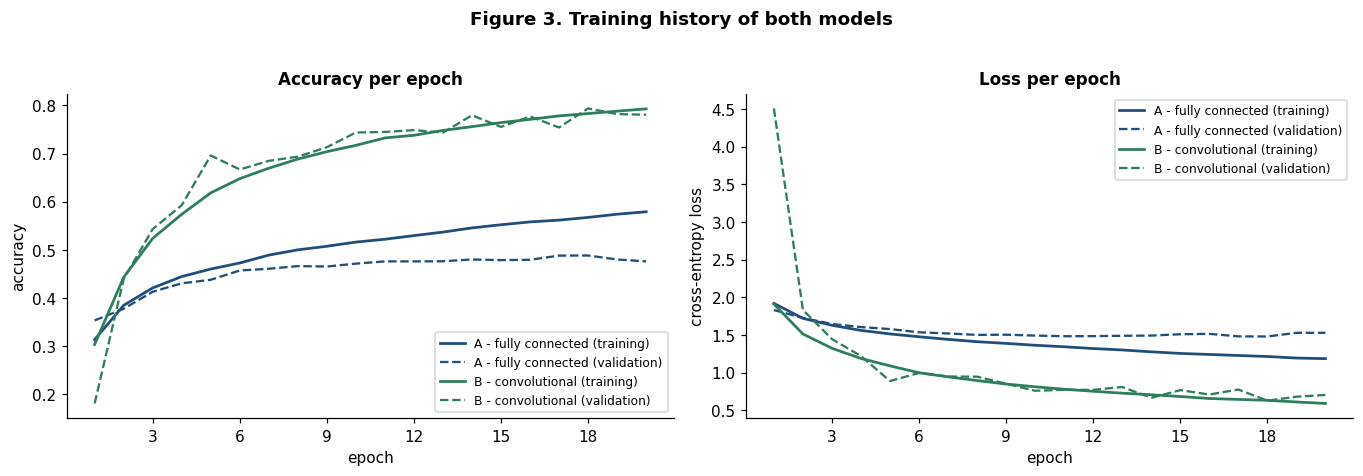

Model A: best validation accuracy 0.4882 at epoch 18 | final training accuracy 0.5791
Model B: best validation accuracy 0.7938 at epoch 18 | final training accuracy 0.7929


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

for history, name, color in [(history_a, 'A - fully connected', BLUE),
                             (history_b, 'B - convolutional', GREEN)]:
    epochs_run = range(1, len(history.history['accuracy']) + 1)
    axes[0].plot(epochs_run, history.history['accuracy'], color=color, lw=1.8,
                 label=name + ' (training)')
    axes[0].plot(epochs_run, history.history['val_accuracy'], color=color, lw=1.5,
                 linestyle='--', label=name + ' (validation)')
    axes[1].plot(epochs_run, history.history['loss'], color=color, lw=1.8, label=name + ' (training)')
    axes[1].plot(epochs_run, history.history['val_loss'], color=color, lw=1.5,
                 linestyle='--', label=name + ' (validation)')

for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))   # epochs are whole numbers

axes[0].set_xlabel('epoch'); axes[0].set_ylabel('accuracy')
axes[0].set_title('Accuracy per epoch', fontweight='bold'); axes[0].legend(fontsize=8)
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('cross-entropy loss')
axes[1].set_title('Loss per epoch', fontweight='bold'); axes[1].legend(fontsize=8)

plt.suptitle('Figure 3. Training history of both models', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

for history, name in [(history_a, 'Model A'), (history_b, 'Model B')]:
    best = int(np.argmax(history.history['val_accuracy']))
    print('%s: best validation accuracy %.4f at epoch %d | final training accuracy %.4f'
          % (name, history.history['val_accuracy'][best], best + 1,
             history.history['accuracy'][-1]))

## 7. Part 2.3 — Evaluating Each Model on the Testing Set

The 5,000 test images have not been used for anything so far. Each model now predicts them once.

All four metrics are built from the same four counts: true positives (TP), false positives (FP), true negatives (TN), and false negatives (FN).

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} \qquad\qquad \text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN} \qquad\qquad \text{F1} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In plain terms, **accuracy** is the share of all images labelled correctly. **Precision** for *cat* asks how much of what the model called a cat really was a cat. **Recall** for *cat* asks how many of the real cats the model actually found. **F1** is their harmonic mean, which stays low unless both are high, so it catches a model that earns good precision by being timid or good recall by guessing freely.

These distinctions decide real deployments. A screening system that must not miss a threat is tuned for recall and accepts false alarms; an automated system that acts without a human in the loop is tuned for precision, because acting on a false positive has a cost.

With ten classes each metric is computed per class and then averaged. **Macro** averaging is the headline, since it weights all ten classes equally. **Weighted** averaging is reported alongside it, and because CIFAR-10 is perfectly balanced the two should land very close together.

In [11]:
probabilities_a = model_a.predict(X_test_flat, batch_size=256, verbose=0)
probabilities_b = model_b.predict(X_test, batch_size=256, verbose=0)
predictions_a = np.argmax(probabilities_a, axis=1)
predictions_b = np.argmax(probabilities_b, axis=1)

def evaluate(y_true, y_pred, seconds, model):
    """All reported metrics for one model, in one dictionary."""
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-score (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'Precision (weighted)': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-score (weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Misclassified images': int((y_true != y_pred).sum()),
        'Training time (s)': round(seconds, 1),
        'Parameters': int(model.count_params()),
    }

results = pd.DataFrame({
    'A - fully connected': evaluate(y_test, predictions_a, seconds_a, model_a),
    'B - convolutional': evaluate(y_test, predictions_b, seconds_b, model_b),
})

def as_text(row_name, value):
    """Score rows print to four decimals; counts print with thousands separators."""
    if row_name in ('Misclassified images', 'Parameters'):
        return format(int(value), ',')
    if row_name == 'Training time (s)':
        return '%.1f' % value
    return '%.4f' % value

formatted = results.astype(object)
for row in results.index:
    for column in results.columns:
        formatted.loc[row, column] = as_text(row, results.loc[row, column])

print('TEST-SET RESULTS on 5,000 unseen images')
print('=' * 58)
print(formatted.to_string())

TEST-SET RESULTS on 5,000 unseen images
                     A - fully connected B - convolutional
Accuracy                          0.4766            0.8080
Precision (macro)                 0.4864            0.8068
Recall (macro)                    0.4766            0.8080
F1-score (macro)                  0.4718            0.8050
Precision (weighted)              0.4864            0.8068
Recall (weighted)                 0.4766            0.8080
F1-score (weighted)               0.4718            0.8050
Misclassified images               2,617               960
Training time (s)                   51.7            1029.9
Parameters                     1,707,274           404,266


### 7.1 Per-class breakdown

The averages above hide where each model actually struggles, so the same three metrics are printed for every class individually.

In [12]:
for name, predictions in [('Model A - fully connected network', predictions_a),
                          ('Model B - convolutional neural network', predictions_b)]:
    print(name)
    print(classification_report(y_test, predictions, digits=4,
                                target_names=CLASS_NAMES, zero_division=0))

Model A - fully connected network
              precision    recall  f1-score   support

    airplane     0.5112    0.5460    0.5280       500
  automobile     0.5691    0.6420    0.6034       500
        bird     0.3682    0.3100    0.3366       500
         cat     0.3739    0.2460    0.2967       500
        deer     0.3832    0.4300    0.4053       500
         dog     0.3642    0.4720    0.4111       500
        frog     0.4510    0.5980    0.5142       500
       horse     0.5581    0.4800    0.5161       500
        ship     0.5648    0.6620    0.6096       500
       truck     0.7197    0.3800    0.4974       500

    accuracy                         0.4766      5000
   macro avg     0.4864    0.4766    0.4718      5000
weighted avg     0.4864    0.4766    0.4718      5000

Model B - convolutional neural network
              precision    recall  f1-score   support

    airplane     0.8515    0.8260    0.8386       500
  automobile     0.9165    0.9220    0.9192       500
     

### 7.2 Where the mistakes land

Accuracy says how often each model is right. The confusion matrices say *which* classes it mixes up. Rows are the true class and columns are the prediction, so everything off the diagonal is an error.

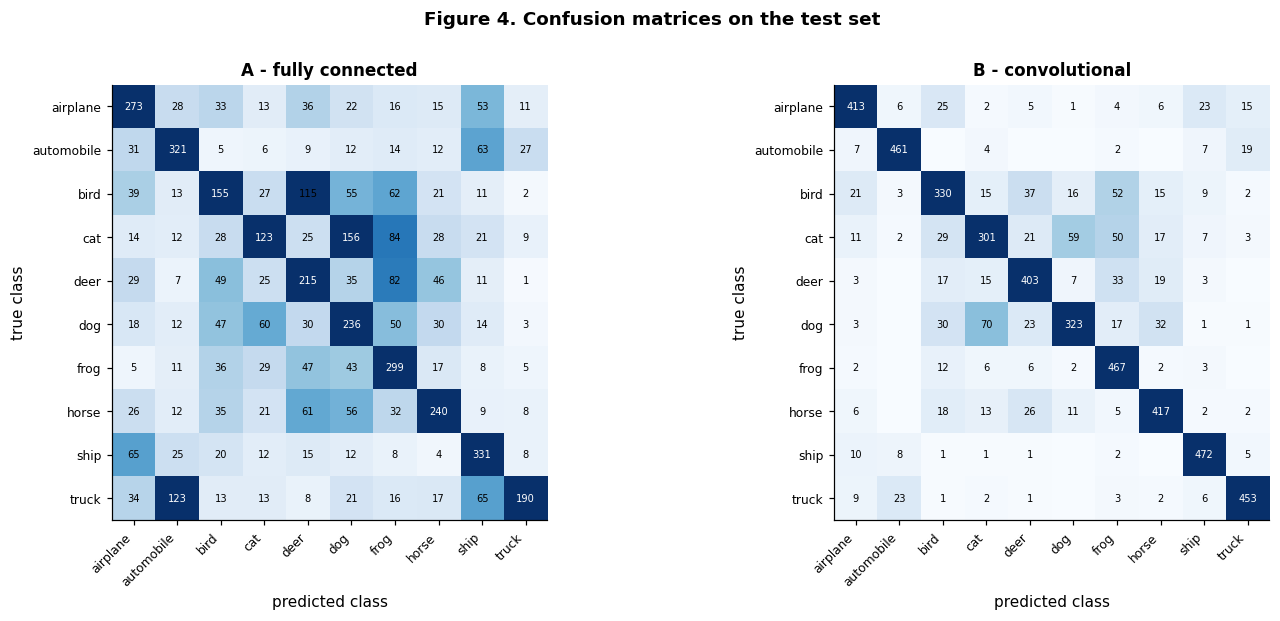

Model A most frequent confusions -> cat read as dog: 156 | truck read as automobile: 123 | bird read as deer: 115 | cat read as frog: 84 | deer read as frog: 82
Model B most frequent confusions -> dog read as cat: 70 | cat read as dog: 59 | bird read as frog: 52 | cat read as frog: 50 | bird read as deer: 37


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.6))

for ax, predictions, title in [(axes[0], predictions_a, 'A - fully connected'),
                               (axes[1], predictions_b, 'B - convolutional')]:
    matrix = confusion_matrix(y_test, predictions)
    ax.imshow(matrix, cmap='Blues', vmin=0, vmax=matrix.max() * 0.35)
    for i in range(10):
        for j in range(10):
            if matrix[i, j] > 0:
                ax.text(j, i, matrix[i, j], ha='center', va='center', fontsize=6.5,
                        color='white' if matrix[i, j] > matrix.max() * 0.35 else 'black')
    ax.set_xticks(range(10)); ax.set_yticks(range(10))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    ax.set_xlabel('predicted class'); ax.set_ylabel('true class')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Figure 4. Confusion matrices on the test set', fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()

# the five largest off-diagonal cells for each model
for name, predictions in [('Model A', predictions_a), ('Model B', predictions_b)]:
    matrix = confusion_matrix(y_test, predictions).copy()
    np.fill_diagonal(matrix, 0)
    worst = np.dstack(np.unravel_index(np.argsort(matrix.ravel())[::-1][:5], matrix.shape))[0]
    pairs = ['%s read as %s: %d' % (CLASS_NAMES[i], CLASS_NAMES[j], matrix[i, j]) for i, j in worst]
    print(name, 'most frequent confusions ->', ' | '.join(pairs))

### 7.3 F1-score for each class

The macro F1 is one number averaged over ten classes. Plotting the ten separately shows whether the improvement is spread evenly or concentrated on particular categories.

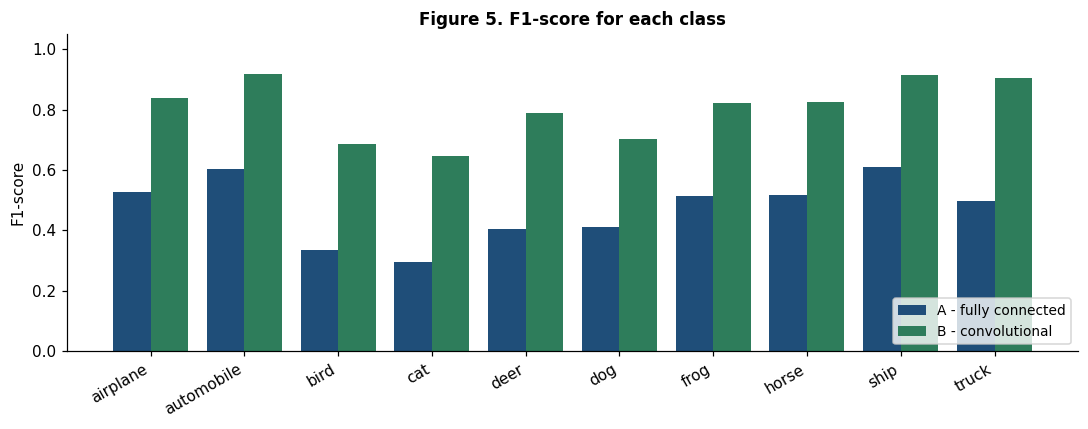

Largest improvement:  truck      (0.497 to 0.906)
Smallest improvement: dog        (0.411 to 0.703)

Hardest class for Model B: cat        (F1 0.648)
Easiest class for Model B: automobile (F1 0.919)


In [14]:
f1_a = f1_score(y_test, predictions_a, average=None, zero_division=0)
f1_b = f1_score(y_test, predictions_b, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 4))
positions = np.arange(10)
width = 0.4
ax.bar(positions - width / 2, f1_a, width, color=BLUE, label='A - fully connected')
ax.bar(positions + width / 2, f1_b, width, color=GREEN, label='B - convolutional')
ax.set_xticks(positions); ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
ax.set_ylabel('F1-score'); ax.set_ylim(0, 1.05)
ax.set_title('Figure 5. F1-score for each class', fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout(); plt.show()

gap = f1_b - f1_a
print('Largest improvement:  %-10s (%.3f to %.3f)'
      % (CLASS_NAMES[int(np.argmax(gap))], f1_a[np.argmax(gap)], f1_b[np.argmax(gap)]))
print('Smallest improvement: %-10s (%.3f to %.3f)'
      % (CLASS_NAMES[int(np.argmin(gap))], f1_a[np.argmin(gap)], f1_b[np.argmin(gap)]))
print()
print('Hardest class for Model B: %-10s (F1 %.3f)'
      % (CLASS_NAMES[int(np.argmin(f1_b))], f1_b.min()))
print('Easiest class for Model B: %-10s (F1 %.3f)'
      % (CLASS_NAMES[int(np.argmax(f1_b))], f1_b.max()))

### 7.4 What the CNN still gets wrong

A last look at the errors themselves. The images below are test images Model B misclassified, shown with the true label, the predicted label, and the confidence the model assigned to its answer.

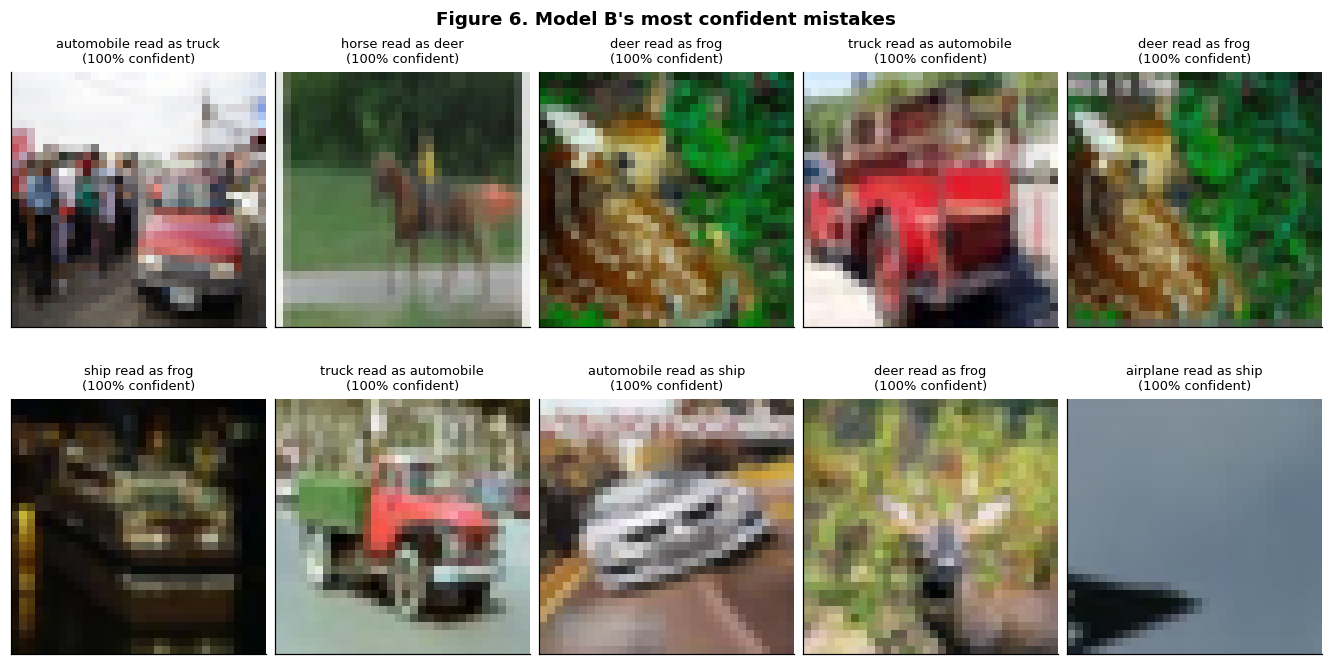

Model B misclassified 960 of 5000 test images (19.20%)
Mean confidence when correct: 0.888 | when wrong: 0.628


In [15]:
wrong = np.flatnonzero(predictions_b != y_test)
confidence = probabilities_b.max(axis=1)

# show the ten errors the model was most confident about, which are the most informative failures
most_confident_errors = wrong[np.argsort(confidence[wrong])[::-1][:10]]

fig, axes = plt.subplots(2, 5, figsize=(12, 6.2), constrained_layout=True)
for ax, index in zip(axes.ravel(), most_confident_errors):
    ax.imshow(images_test[index])
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title('%s read as %s\n(%.0f%% confident)'
                 % (CLASS_NAMES[y_test[index]], CLASS_NAMES[predictions_b[index]],
                    100 * confidence[index]), fontsize=8.5)

plt.suptitle('Figure 6. Model B\'s most confident mistakes', fontsize=12, fontweight='bold')
plt.show()

print('Model B misclassified %d of %d test images (%.2f%%)'
      % (len(wrong), len(y_test), 100 * len(wrong) / len(y_test)))
print('Mean confidence when correct: %.3f | when wrong: %.3f'
      % (confidence[predictions_b == y_test].mean(), confidence[wrong].mean()))

## 8. Part 2.4 — Comparing the Two Models

The table in Section 7 is the summary: the convolutional network beats the fully connected network on accuracy, precision, recall, and F1-score simultaneously, and it does so while using roughly **4.2 times fewer parameters**. Model A reached 47.66% accuracy against Model B's 80.80%, a gap of 33.1 percentage points, and 960 misclassified images against 2,617 on the same 5,000 pictures, which is 2.7 times fewer errors. Macro and weighted averages are identical to four decimal places for both models, which is exactly what a perfectly balanced test set should produce: with 500 images in every class, the two averaging schemes are mathematically forced to agree. That agreement is a sanity check on the split rather than evidence about per-class performance, which Section 7.1 covers separately.

Four points explain the gap.

**1. The difference is real, not an artifact of one metric.** The four metrics move together almost exactly: accuracy and recall both improve by 33.1 points, precision by 32.0, and F1 by 33.3. Those metrics fail in different ways, so when all of them shift by the same margin the cause is the model rather than a quirk of a single score.

**2. The root cause is the geometry that flattening destroys.** This is the main explanation, and Section 6.1 set it up. Both models received exactly the same pixels. Model A received them as an unordered vector of 3,072 numbers, which means the fact that pixel 1 sits next to pixel 2 was deleted before training began. It cannot represent an edge, because an edge is a statement about neighbouring pixels. It cannot recognise the same object in a new position, because a shifted object is an entirely different input vector. Model B keeps the grid and, by Formula 1, computes over neighbourhoods, so edges and textures are available to it from the first layer, and by Formula 7 it learns each kernel from evidence gathered across the whole frame.

The parameter counts sharpen the point rather than weakening it. Model A is the *larger* model, with roughly 1.7 million weights against Model B's 400,000, and it still loses badly. Extra capacity spent on the wrong structure does not help. The training curves in Figure 3 show the same thing from another angle. Model A finished at 57.91% on the training images but only 48.82% on validation, a nine-point gap that is the signature of a network memorising individual images because it has no general rule available to learn. Model B finished at 79.29% training and 79.38% validation, essentially no gap at all, so its dropout and pooling are holding overfitting off entirely and its errors are genuine difficulty rather than memorisation.

**3. The per-class gaps point at the same cause.** Figure 5 shows the improvement is uneven. The four vehicle classes take the top four F1-scores under Model B, automobile at 0.919, ship at 0.914, truck at 0.906, and airplane at 0.839, while the three hardest are all animals: cat at 0.648, bird at 0.685, and dog at 0.703. Vehicles have rigid outlines and characteristic straight edges. Cats, birds, and dogs are deformable, appear in many poses, and at 32 x 32 pixels a small animal is a handful of texture patches.

Truck is the sharpest illustration of why F1 was worth reporting. Model A scored 0.7197 precision on trucks but only 0.3800 recall: when it committed to truck it was usually right, but it found barely a third of them, and F1 collapsed the pair to 0.4974. Model B lifts truck to 0.9060 with precision and recall balanced at 0.906 each. That is the largest per-class gain in the report, and accuracy alone would never have exposed the imbalance underneath it.

**4. Confident errors are informative errors.** Figure 6 shows the ten mistakes Model B was most certain about, and they fall into two groups. Several sit on genuinely blurred category boundaries, such as a red pickup labelled automobile that the model read as truck, and a fire truck labelled truck that it read as automobile. The rest are objects lost in their background, such as deer standing in dense foliage that the model read as frog, which is the green-texture response overwhelming the shape. Almost none look like careless errors, and and Model B's most frequent confusion overall was dog read as cat, 70 times. This matters for the security framing in the introduction.

**What the baseline still shows.** Model A is not useless: at 47.66% it is nearly five times better than the 10% a coin-flip across ten classes would give, so the pixels do carry usable signal even without geometry. It also trains in a fraction of the time, 51.7 seconds against 1,029.9 seconds, roughly twenty times faster, which is the real trade the convolutional stack demands. It sets the floor that the architecture has to beat, and the size of the margin above that floor is the measurement this report set out to make.

**Where Model B would go next.** The obvious next steps, in order of expected return: data augmentation with random flips and small shifts, which typically adds several points by manufacturing the positional variety the training set lacks; a longer schedule with a learning-rate decay; and transfer learning from a network pretrained on a larger corpus, which is what a production system in the security domain would actually use.

## 9. Conclusion

Part 1 laid out the machinery. A convolution passes a small kernel over the image and computes a weighted sum at every position, which is Formula 1, and because the same kernel is reused everywhere the layer's cost depends only on the kernel size and channel counts, which is Formula 3. ReLU supplies the non-linearity, max pooling shrinks the map while adding tolerance to small shifts, and a fully connected head with softmax turns the final features into ten probabilities. Formula 7 is where the design closes the loop: each kernel's gradient is summed over every position it visited, so one image updates every kernel with evidence from the whole frame. Figure 1 drew that sequence and marked the formulas onto the stages that carry them out.

Part 2 tested the design on 50,000 labelled CIFAR-10 photographs, split 45,000 for training and 5,000 for testing. Both models received identical pixels, identical scaling, identical optimizer settings, and the same held-out test set, so the results isolate one variable: whether the model is allowed to know that the input is a grid. The fully connected baseline, the larger of the two models at 1,707,274 parameters, reached 47.66% accuracy with a macro F1 of 0.4718. The convolutional network, at 404,266 parameters, reached 80.80% accuracy with macro precision 0.8068, recall 0.8080, and F1 0.8050, and cut the error count from 2,617 images to 960.

The practical lesson is the one the parameter counts make hardest to miss. The weaker model was the bigger one. Capacity did not decide the outcome; matching the architecture to the structure of the data did. For the security application in the introduction, that is the difference between an alert stream an operator ignores and one they act on, and Figure 6 points at how such a system should be built: not on the assumption that the model is always right, but on a confidence threshold that sends the genuinely ambiguous frames to a person.

## 10. Part 3 — Screencast Video

The screencast walks through this notebook: the convolution formulas and the diagram from Part 1, then the live run of Part 2, covering the load, the split, the preprocessing, the training of both models, and the comparison on accuracy, precision, recall, and F1-score.

**Video link:** https://teams.cloud.microsoft/l/meetingrecap?driveId=b%21xMuWoS0KFki6uyy0srElJvzd9gH96QxKu2dfGKR4_OVLH6IMWBjPSKcSW_XDu84w&driveItemId=01IPKWKP75V2KXFVDIGNGIVSFGRUBUVSXK&sitePath=https%3A%2F%2Fmygcuedu6961.sharepoint.com%2Fsites%2FPrithvi_coding%2FShared+Documents%2FGeneral%2FRecordings%2FCNN+5-20260812_152307-Meeting+Recording.mp4%3Fweb%3D1&fileUrl=https%3A%2F%2Fmygcuedu6961.sharepoint.com%2Fsites%2FPrithvi_coding%2FShared+Documents%2FGeneral%2FRecordings%2FCNN+5-20260812_152307-Meeting+Recording.mp4%3Fweb%3D1&threadId=19%3AfOVT62R7RGi4W0cWZU21YHT9fQiJaUmwe3UIVhxMCuU1%40thread.tacv2&organizerId=f9829dd1-6d2c-4939-a8ef-6392cd1fd463&tenantId=389b2929-5a30-4683-9c8c-1d21434d57e7&callId=a9de0c7f-a3fb-41ab-a6f4-38a35dbae50f&threadType=space&meetingType=MeetNow&organizerGroupId=5ee13641-3a73-4722-a7cc-a5a0e95c00c1&channelType=Standard&replyChainId=1786562574771&subType=RecapSharingLink_RecapCore&recapType=RecordingAndTranscript

## 11. References

Chollet, F. (2021). *Deep learning with Python* (2nd ed.). Manning Publications.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep learning*. MIT Press.

Ioffe, S., & Szegedy, C. (2015). Batch normalization: Accelerating deep network training by reducing internal covariate shift. *Proceedings of the 32nd International Conference on Machine Learning*, 448-456.

Kaggle. (2013). *CIFAR-10 - Object recognition in images* [Data set]. https://www.kaggle.com/competitions/cifar-10

Kingma, D. P., & Ba, J. (2015). Adam: A method for stochastic optimization. *International Conference on Learning Representations*.

Krizhevsky, A. (2009). *Learning multiple layers of features from tiny images* [Technical report]. University of Toronto.

Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). ImageNet classification with deep convolutional neural networks. *Advances in Neural Information Processing Systems, 25*, 1097-1105.

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. *Proceedings of the IEEE, 86*(11), 2278-2324.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: A simple way to prevent neural networks from overfitting. *Journal of Machine Learning Research, 15*(1), 1929-1958.

### AI Usage Disclosure

I used AI tools to help with grammar, markdown formatting, and beautifying graph code. All analysis, interpretations, and conclusions are my own work.